# 18.335 Problem Set 3
Simon Opsahl (sopsahl@mit.edu)

May 4, 2025

# Problem 0: Pset Honor Code

I will not look at 18.335 pset solutions from previous semesters. I may discuss problems with my classmates or others, but I will write up my solutions on my own. 

# Problem 1: Pseudospectra

In this problem, we are asked to show equivalence between conditions of the pseudospectra of $A\in \mathbb{C}^{n \times n}$. Given a fixed parameter $\epsilon >0$, $\Lambda_{\epsilon}(A)$ is the set of $z\in\mathbb{C}$ that satisfies such conditions. The conditions are as follows:
1. $z$ is an eigenvalue of $A + \delta A$ and $\|\delta A\|_2 \le \epsilon$
2. $\exists u \in \mathbb{C}^n$ and $\|u\|_2 = 1$ such that $ \|(A - zI)u\|_2 \le \epsilon $
3. $\sigma_n(zI - A) \le \epsilon$
4. $\|(zI - A)^{-1}\|_2 \ge \epsilon^{-1}$ (with the convention that if $(zI - A)$ is singular, then the norm is infinite)

We can establish equivalence through the following relation:

$$  (4) \implies (3) \implies (2) \implies (1) \implies (4) $$

We create a cycle, and thus the conditions are equivalent.

### (4) $\implies$ (3)

By definition, we know that if $zI -A$ is invertible, then the norm of its inverse is equal to the reciprocal of the smallest singular value. As a result, 
$$ \sigma_n(zI - A) = \frac{1}{\|(zI -A)^{-1}\|_2} \le \frac{1}{\epsilon^{-1}} = \epsilon$$

### (3) $\implies$ (2)

By definition, the smallest eigenvalue of a matrix is the minimum amount that the matrix can stretch a unit vector. In other words:

$$  \sigma_n(zI - A) = \min _{\|u\|_2 = 1} \|(zI - A)u\|_2 $$

Thus, if $\sigma_n(zI - A) \le \epsilon$, then there must exist a $u$ that minimizes our norm such that

$$ \|(zI - A)u\|_2  \le \epsilon$$



### (2) $\implies$ (1)
If we let $z, u$ be an eigenpair of $A + \delta A$, then 
$$(A + \delta A) u = zu$$
As a result, 
$$(A-zI)u = -\delta A u$$
$$ \|(A - zI)u\|_2 = \|-\delta A u\|_2 \le \| \delta A\|_2 \|u\|_2 =  \| \delta A\|_2 \le \epsilon$$



### (1) $\implies$ (4)
 As before, if we let $z, u$ be an eigenpair of $A + \delta A$, then $(A + \delta A) u = zu$, and thus

$$u = (zI - A)^{-1} \delta A u$$
if $zI -A$ is invertible. If it is not, then (4) is trivially true as the inverse norm is infinite.

$$\|u\|_2 = \|(zI - A)^{-1} \delta A u\|_2 \le \|(zI - A)^{-1}\|_2 \| \delta A\|_2 \| u\|_2$$
We know that $\|u\|_2 = 1$ and $\|\delta A\| \le \epsilon$. As a result,
$$ 1 \le \|(zI - A)^{-1}\|_2 \| \delta A\|_2 \le \|(zI - A)^{-1}\|_2 \cdot \epsilon$$

$$\|(zI - A)^{-1}\|_2 \ge \epsilon^{-1}$$

# Problem 2: Newton's Method for the Eigenvalue Problem

In this problem, we are asked to use Newton's update method to construct an iterative algorithm for computing eigenpairs of a matrix $A$. In order to construct our algorithm, we must define a function 

$$
F \left ( \begin{bmatrix}
x \\
\lambda
\end{bmatrix}
\right)
$$ 
that will converge to 0. We rely on two constraints of our problem: $(A-\lambda I)x$ and $\frac{1}{2}(x^Tx -1)$. 

We can construct the matrix


$$
F =  \begin{bmatrix}
(A-\lambda I)x \\
\frac{1}{2}(x^Tx -1)
\end{bmatrix}

$$ 

and find the Jacobian as 

$$
J[F] = \begin{bmatrix}
(A-\lambda I) & -x \\
x^T & 0
\end{bmatrix}
$$ 

If we define $x_t = x_{t-1} + \delta x$ and $\lambda_t = \lambda_{t-1} + \delta \lambda$, then we can construct our update problem as the linear system

$$
J[F]\begin{bmatrix}
\delta x \\
\delta \lambda
\end{bmatrix} = 
- F 
$$
$$ 
\begin{bmatrix}
(A-\lambda I) & -x \\
x^T & 0
\end{bmatrix}\begin{bmatrix}
\delta x \\
\delta \lambda
\end{bmatrix} = -\begin{bmatrix}
(A-\lambda I)x \\
\frac{1}{2}(x^Tx -1)
\end{bmatrix}
$$ 

If we normalize $x$ at each time step, then we know that $x^Tx = 1$, and thus 

$$ 
\begin{bmatrix}
(A-\lambda I) & -x \\
x^T & 0
\end{bmatrix}\begin{bmatrix}
\delta x \\
\delta \lambda
\end{bmatrix} = -\begin{bmatrix}
(A-\lambda I)x \\
0
\end{bmatrix}
$$

We end up with the two equations

$$(A- \lambda I)\delta x - \delta\lambda x= -(A - \lambda I)x$$
$$ x^T \delta x = 0$$

We can solve for $\delta x$ as 

$$\delta x  = (A- \lambda I)^{-1}\delta\lambda x-x$$

If $x^T\delta x = 0$, then 

$$0  = x^T(A- \lambda I)^{-1}\delta\lambda x-x^Tx = x^T(A- \lambda I)^{-1}\delta\lambda x-1$$

and 

$$ \delta \lambda = \frac{1}{x^T(A- \lambda I)^{-1}x}$$

As a result, 

$$ \delta x = (A- \lambda I)^{-1}\delta\lambda x-x$$

We then define our algorithm for computing an eigenpair of $A$ as the following:

Initialize $x_0$ (with $\|x_0\| = 1$), and $\lambda_0$

For $t = 1, 2, 3, \dots$
$$\lambda_t = \lambda_{t-1} + \frac{1}{x_{t-1}^T(A - \lambda_{t-1} I)^{-1} x_{t-1}}$$

If $\lambda_t \approx \lambda_{t-1}$, break. Else

$$\hat{x}_t = (A- \lambda_{t-1} I)^{-1} x_{t-1}$$
$$x_t = \frac{\hat{x}_t}{\|\hat{x}_t\|}$$



This algorithm is identical to the Rayleigh Quotient Iteration in the update of $x_t$. For the estimation of the corresponding eigenvalue, however, we use a different update using the gradient of the current $\lambda_{t-1}$ as opposed to the direct eigenvalue estimator $R(x_{t-1})$.



# Problem 4: Arnoldi Iteration in Action

In this problem, we are asked to consider the bidiagonal $n\times n$ matrix $A$, where $A_{k, k} = A_{k, k + 1} = k^{-\frac{1}{2}}$ and $n=64$.


In [1]:
using LinearAlgebra, Random, Plots

In [2]:
N = 64
A = [i==j ? 1/sqrt(i) : j==i+1 ? 1/sqrt(i) : 0 for i = 1:N, j=1:N]

64×64 Matrix{Real}:
 1.0  1.0       0         0        0         …  0         0         0
 0    0.707107  0.707107  0        0            0         0         0
 0    0         0.57735   0.57735  0            0         0         0
 0    0         0         0.5      0.5          0         0         0
 0    0         0         0        0.447214     0         0         0
 0    0         0         0        0         …  0         0         0
 0    0         0         0        0            0         0         0
 0    0         0         0        0            0         0         0
 0    0         0         0        0            0         0         0
 0    0         0         0        0            0         0         0
 ⋮                                           ⋱                      
 0    0         0         0        0         …  0         0         0
 0    0         0         0        0            0         0         0
 0    0         0         0        0            0         0         0
 

## part (a)

We are asked to plot the spectrum of $A$ and the boundaries of the pseudospectra of $A$ for $\epsilon = 10^{-i}$.

The spectrum is just the set of eigenvalues of $A$, which happen to be each of the diagonal elements. The pseudospectra, or $\Lambda_\epsilon(A)$, can be found as the set of $z$ that satisfy the expression $\sigma_n(zI - A) \le \epsilon$. 

In [3]:
function plotSpectrum(M, label)

    eigenvalues = eigvals(M)
    scatter!(real.(eigenvalues), imag.(eigenvalues), markersize = 3, label=label)
    
end

function plotPseudospectrum(M)
    
    x = LinRange(-0.5, 1.5, 200)
    y = LinRange(-0.8, 0.8, 200)
    Z = [complex(xi, yi) for yi in y, xi in x]

    sigmas = [minimum(svdvals(z*I - M)) for z in Z]
    
    contour!(x, y, sigmas, levels=[1e-1, 1e-2, 1e-3, 1e-4], linewidth=1, label="Pseudospectrum", colorbar=false)

end

plotPseudospectrum (generic function with 1 method)

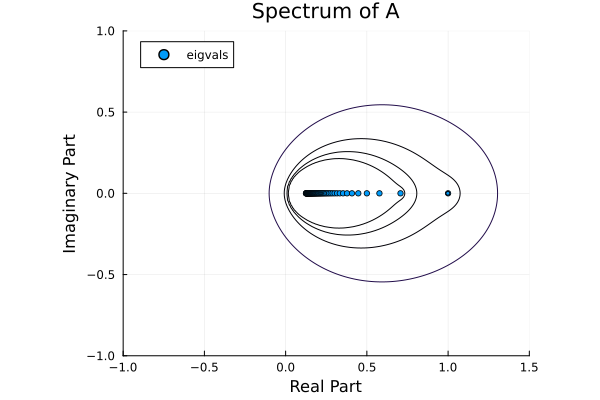

In [4]:
# spectrum of A
plot(title = "Spectrum of A", ylim=[-1, 1], xlim=[-1, 1.5], aspect_ratio=:equal)
plot!(xlabel = "Real Part", ylabel = "Imaginary Part")
plotSpectrum(A, "eigvals")
plotPseudospectrum(A)
display(current())

## part (b)
We are asked to plot the convergence of the Arnoldi iteration for the two largest eigenvalues of $A$ as well as its smallest. We first compute the $H$ matrix for each step of the iteration. We then use the eigenvalues of $H_k$ to estimate $k$ eigenvalues of $A$ at each timestep.

In [5]:
K = 20

x = randn(Complex{Float64}, N)
Q = zeros(Complex{Float64}, N, K+1)
H = zeros(Complex{Float64}, K, K+1)

# Arnoldi's Algorithm
Q[:, 1] = x/norm(x)
for k in 1:K
    w = A * Q[:, k]
    for j in 1:k
        H[j, k] = Q[:, j]' * w
        w = w - H[j, k] * Q[:, j]
    end
    H[k, k+1] = norm(w)
    if H[k, k+1] == 0
        break
    end

    Q[:, k+1] = w / norm(w)

end


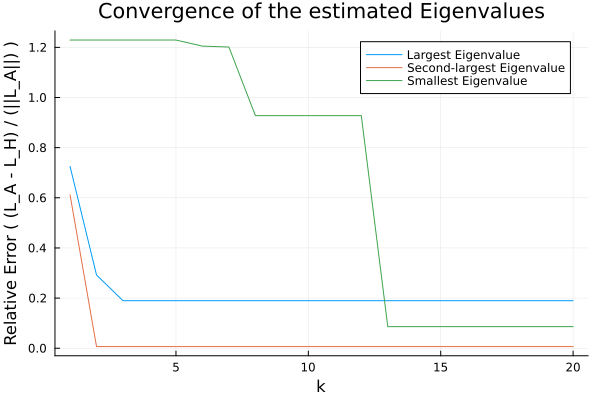

In [6]:
# Plotting the convergence of the spectrum
eigvalues = sort((eigvals(A)), rev=true)
errors = zeros(Float64, K, 3)

for k in 1:K 
    estimated_eigvals = eigvals(H[1:k, 1:k])
    errors[k, 1] = minimum(abs.(estimated_eigvals .- eigvalues[1])) / eigvalues[1]
    errors[k, 2] = minimum(abs.(estimated_eigvals .- eigvalues[2])) / eigvalues[2]
    errors[k, 3] = minimum(abs.(estimated_eigvals .- eigvalues[N])) / eigvalues[N]
end

plot([1:K], errors[:, 1], label="Largest Eigenvalue")
plot!([1:K], errors[:, 2], label="Second-largest Eigenvalue")
plot!([1:K], errors[:, 3], label="Smallest Eigenvalue")
xlabel!("k")
ylabel!("Relative Error ( (L_A - L_H) / (||L_A||) )")
title!("Convergence of the estimated Eigenvalues")
display(current())

From the plot, we see that the error between the largest and second-largest eigenvalue initially decrease, then level out at $k=3$. We also see that the smallest eigenvalue has a higher  relative error until later timesteps. Further investigation is needed to see the convergence of the eigenspace over time, but this plot is evidence that the Arnoldi iteration is an effective approximator of large eigenvalues with a $k << n$ and smaller eigenvalues with a $k < n$.

## part (c)

We are asked to plot the spectrum of $H$ at different iterations. We notice that as $k$ increases, the spectrum more closely resembles that of $A$. The convergence is slow, however, and the shape of the pseudospecturm is affected significantly by the complex components of the spectrum of $H_k$.

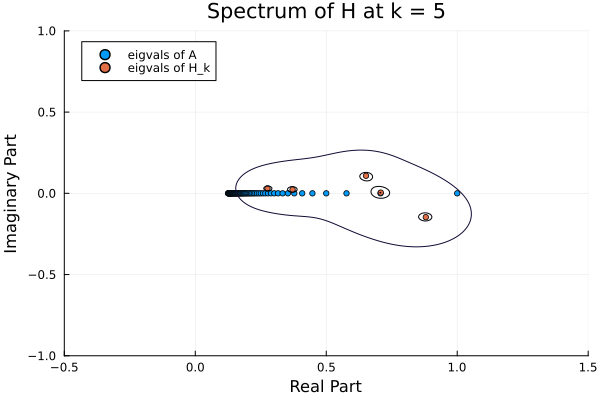

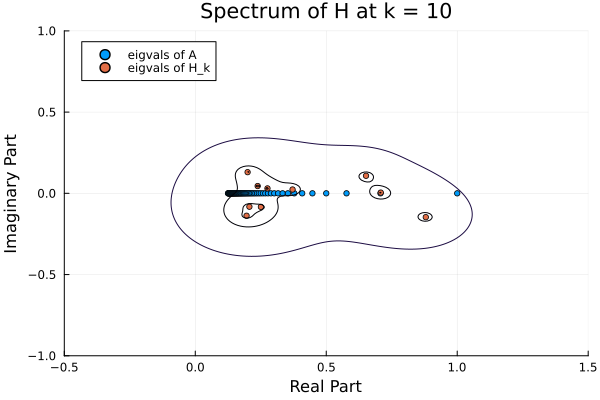

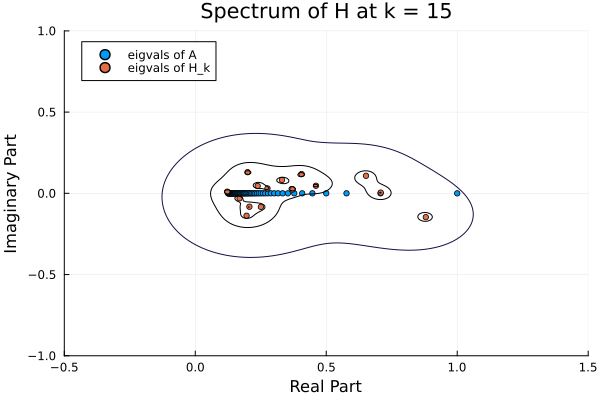

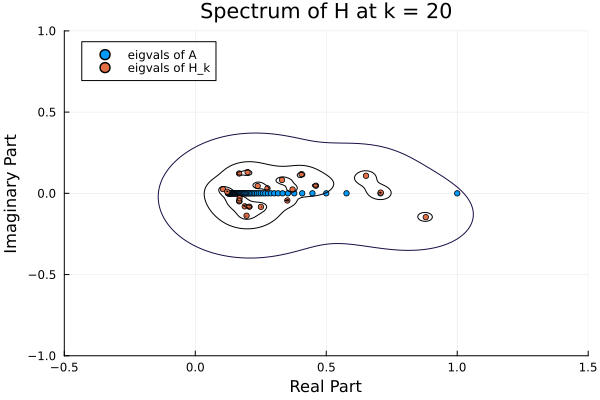

In [9]:
for k in [5, 10, 15, 20]
    plot(xlabel = "Real Part", ylabel = "Imaginary Part", title = "Spectrum of H at k = $(k)")
    plotSpectrum(A, "eigvals of A")
    plotSpectrum(H[1:k, 1:k], "eigvals of H_k")
    plotPseudospectrum(H[1:k, 1:k])
    plot!(ylim=[-1, 1], xlim=[-0.5, 1.5])
    display(current())
end